## Plot range of SIGGMA data versus CHORD range

In [38]:
import numpy as np
import pandas as pd
from numpy import log, sqrt, pi, exp, cos, sin
import healpy as hp
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import matplotlib.patches as patches
from astropy.io import fits

from pygdsm import GlobalSkyModel16 

%load_ext autoreload
%autoreload 2

from CHORD_Sensitivity import SkyMap
from CHORD_Sensitivity import Telescope
from CHORD_Sensitivity.constants import CLEAN_LINES

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [39]:
## Physical Constants
k_b = 1.38e3 # Boltzmann constant in Jy K^(-1) m^2
omega = 7.29e-5  # Earth rotation rate in rad/s
c = 3e8  # speed of light in m/s

## CHORD Constants
t_sys = 30 # kelvin
bandwidth = 5e3  # 5 kHz
Efficiency = 0.5 # unitless
dish_diameter = 6  # meters
A_e = np.pi * (dish_diameter / 2)**2 * Efficiency  # m^2
SEFD = 2 * k_b * t_sys / A_e  # Jy
N = 512 # number of CHORD dishes
N_b = N * (N - 1)  # number of independent noise baselines
dec = 49.3 # CHORD declination in degrees
dec_radians = np.radians(dec)
N_EW = 22  # ndish_ew
N_NS = 24  # ndish_ns
D_EW = N_EW * 6.3  # dish_seperation_ew (m)
D_NS = N_NS * 8.5  # dish_seperation_ns (m)

In [40]:
sky_map = SkyMap('CHORD')

background_map = sky_map.sky_noise(delta_nu=5e3, freq=500e6, type='background_only', CHORD_range=False)
background_map_chord = sky_map.sky_noise(delta_nu=5e3, freq=500e6, type='background_only', CHORD_range=True)


/opt/anaconda3/envs/rrl/lib/python3.10/site-packages/healpy/visufunc.py:200: UserWarning: Ignoring specified arguments in this call because figure with num: 1 already exists
  f = pylab.figure(fig, figsize=(8.5, 5.4))


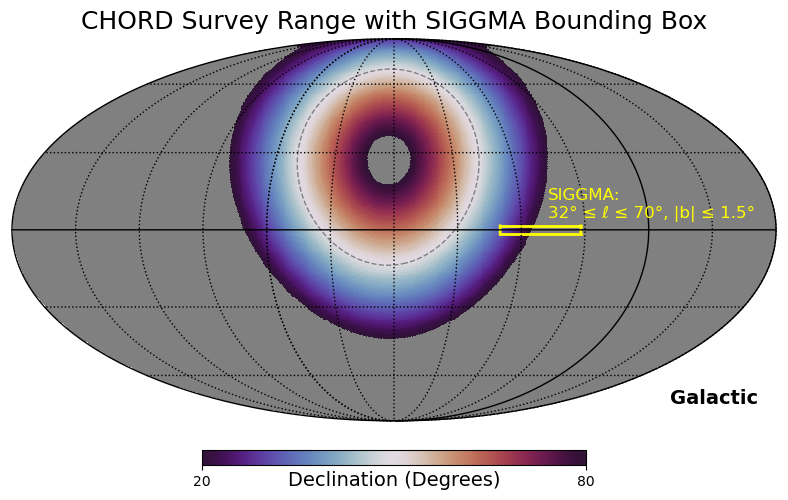

In [41]:
# --- Build a HEALPix map of CHORD's survey range ---
# For each candidate pointing declination, the instantaneous beam traces a
# constant-colatitude arc on the sky. We rasterize every arc and keep, per
# pixel, the lowest declination that reaches it.
nside = 128
CHORD_angles = np.linspace(20, 80, 100)        # pointing declinations (deg N)
phi = np.linspace(0, 2 * np.pi, 10000)         # dense azimuthal sampling

hp_map = np.full(hp.nside2npix(nside), np.nan)
for dec_deg in CHORD_angles:
    theta = np.deg2rad(90 - dec_deg)
    pixels = hp.ang2pix(nside, np.full_like(phi, theta), phi)
    hp_map[pixels] = np.fmin(hp_map[pixels], dec_deg)

dec_center = np.deg2rad(90 - dec)

# --- Survey bounding boxes in Galactic coordinates (l_min, l_max, b_min, b_max) ---
boxes = {
    'SIGGMA': dict(bounds=(32, 70, -1.5, 1.5), color='yellow'),
    #'GDIGGS': dict(bounds=(-5, 32, -0.5, 0.5), color='navy'),
}

def draw_galactic_box(l_min, l_max, b_min, b_max, color, lw=2):
    """Draw a rectangle in Galactic coords (healpy uses theta = 90 - b)."""
    l = np.deg2rad([l_min, l_max])
    t = np.deg2rad([90 - b_min, 90 - b_max])
    edges = [
        (np.full(100, t[0]), np.linspace(*l, 100)),   # bottom (b_min)
        (np.full(100, t[1]), np.linspace(*l, 100)),   # top    (b_max)
        (np.linspace(*t, 100), np.full(100, l[0])),   # left   (l_min)
        (np.linspace(*t, 100), np.full(100, l[1])),   # right  (l_max)
    ]
    for theta, phi_ in edges:
        hp.projplot(theta, phi_, lonlat=False, coord='G', color=color, lw=lw)

# --- Plot in Galactic coordinates ---
fig = plt.figure(figsize=(8, 6))
plt.rcParams["axes.titlesize"] = 18
hp.mollview(
    hp_map, fig=fig, title='CHORD Survey Range with SIGGMA Bounding Box',
    cmap='twilight_shifted', unit='Declination (Degrees)',
    coord=['C', 'G'], rot=(120, 0))
hp.projplot(np.full_like(phi, dec_center), phi, lw=1, color='grey',
            linestyle='dashed', coord='C')

for box in boxes.values():
    draw_galactic_box(*box['bounds'], color=box['color'])

hp.graticule()
plt.gca().text(
    0.7, 0.565, "SIGGMA:\n32° ≤ ℓ ≤ 70°, |b| ≤ 1.5°", color="yellow",
    fontsize=12, transform=plt.gca().transAxes, verticalalignment="center")
plt.savefig('../../thesis/plots/siggma/siggma_range_map.png', dpi=100)
plt.show()

## Plot SIGGMA data

Processing: G32.5+0.ha.2pol.fix.20170324_WGTMED.fits


/var/folders/1v/pf54418j6fj5541rk7ynqhgw0000gn/T/ipykernel_6919/1875000001.py:37: RuntimeWarning: All-NaN slice encountered
  moment0_max = np.nanmax(cube, axis=0)


Processing: G37.5+0.ha.2pol.fix.20170324_WGTMED.fits
Processing: G42.5+0.ha.2pol.fix.20170324_WGTMED.fits
Processing: G47.5+0.ha.2pol.fix.20170324_WGTMED.fits
Processing: G52.5+0.ha.2pol.fix.20170324_WGTMED.fits
Processing: G57.5+0.ha.2pol.fix.20170324_WGTMED.fits
Processing: G62.5+0.ha.2pol.fix.20170324_WGTMED.fits
Processing: G67.5+0.ha.2pol.fix.20170324_WGTMED.fits


/opt/anaconda3/envs/rrl/lib/python3.10/site-packages/healpy/visufunc.py:1504: HealpyDeprecationWarning: "verbose" was deprecated in version 1.15.0 and will be removed in a future version. 
  ax.graticule(dpar=dpar, dmer=dmer, coord=coord, local=local, **kwds)


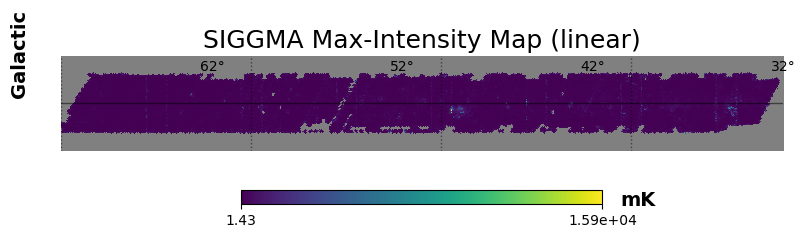

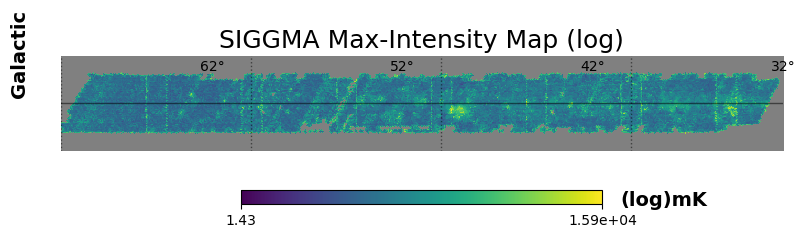

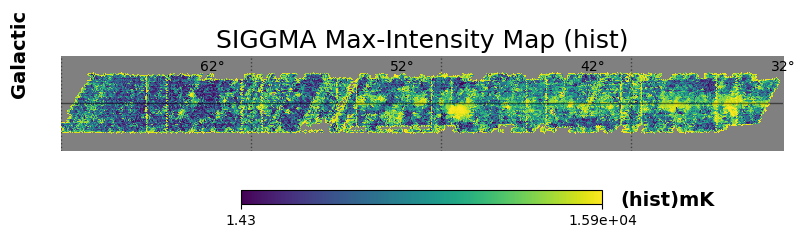

In [42]:
import os
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.wcs import WCS

# ============================================================
# 1) LOAD + MERGE SIGGMA FILES INTO A HEALPIX MAP
# ============================================================
def load_SIGGMA_map(nside, base_path="../../SIGGMA_DATA"):
    fnames = [
        "G32.5+0.ha.2pol.fix.20170324_WGTMED.fits",
        "G37.5+0.ha.2pol.fix.20170324_WGTMED.fits",
        "G42.5+0.ha.2pol.fix.20170324_WGTMED.fits",
        "G47.5+0.ha.2pol.fix.20170324_WGTMED.fits",
        "G52.5+0.ha.2pol.fix.20170324_WGTMED.fits",
        "G57.5+0.ha.2pol.fix.20170324_WGTMED.fits",
        "G62.5+0.ha.2pol.fix.20170324_WGTMED.fits",
        "G67.5+0.ha.2pol.fix.20170324_WGTMED.fits"
    ]

    # Prepare HEALPix container
    npix = hp.nside2npix(nside)
    hmap = np.ones(npix) * hp.UNSEEN

    # Loop through SIGGMA subcubes
    for fname in fnames:
        print("Processing:", fname)

        path = os.path.join(base_path, fname)
        hdul = fits.open(path)
        cube = hdul[0].data      # (vel, lat, lon)
        hdr  = hdul[0].header

        # Max collapse over velocity axis
        moment0_max = np.nanmax(cube, axis=0)

        # Build WCS for pixel → galactic transform
        w = WCS(hdr, naxis=2)
        ny, nx = moment0_max.shape
        y, x = np.indices((ny, nx))
        lon, lat = w.wcs_pix2world(x, y, 0)

        # Convert to healpy angles
        theta = np.radians(90 - lat)
        phi   = np.radians(lon)
        pix   = hp.ang2pix(nside, theta, phi)

        # Flatten for grouping
        pix_flat = pix.flatten()
        vals_flat = moment0_max.flatten()

        # Replace non-finite with -inf before max combine
        vals_flat = np.where(np.isfinite(vals_flat), vals_flat, -np.inf)

        # Group by pixel index
        unique_pix, inverse = np.unique(pix_flat, return_inverse=True)
        unique_vals = np.full_like(unique_pix, -np.inf, dtype=vals_flat.dtype)

        # Max of duplicates
        np.maximum.at(unique_vals, inverse, vals_flat)

        # Insert into global map
        mask_new = (hmap[unique_pix] == hp.UNSEEN)
        hmap[unique_pix[mask_new]] = unique_vals[mask_new]

        mask_overlap = ~mask_new
        hmap[unique_pix[mask_overlap]] = np.maximum(hmap[unique_pix[mask_overlap]],
                                                    unique_vals[mask_overlap])

        hdul.close()

    # Convert UNSEEN / -inf → NaN for plotting
    SIGGMA_map = np.where(np.isin(hmap, (hp.UNSEEN, -np.inf)), np.nan, hmap)

    return SIGGMA_map



# ============================================================
# 2) PLOT SIGGMA HEALPIX MAP WITH CUSTOM LIMITS
# ============================================================
def plot_map(map, lonra, latra, title, 
            units='mK', norm="linear", longitude_labels=True,
            file_path=None):
    """
    Plot SIGGMA HEALPix map using cartview with custom lon/lat ranges.

    Parameters
    ----------
    SIGGMA_map : array
        HEALPix map produced by load_SIGGMA_map()
    lonra : list [lon_min, lon_max]
    latra : list [lat_min, lat_max]
    norm : str ('linear', 'log', 'hist')
    """
    # Disable norm for linear
    norm_to_use = None if norm == "linear" else norm

    hp.cartview(
        map,
        coord='G',
        lonra=lonra,
        latra=latra,
        cmap='viridis',
        norm=norm_to_use,
        title=title + f" ({norm})",
        unit=f"({norm})" + units if norm != "linear" else units
    )

    hp.graticule(dpar=1, dmer=10, coord='G', alpha=0.5, color='black', verbose=False)

    # Optional longitude labels across the top
    if longitude_labels:
        ax = plt.gca()
        for lon in range(int(lonra[0]), int(lonra[1])+1, 10):
            ax.text(-lon, latra[1] - 0.2, f"{lon}°",
                    ha='center', va='top', fontsize=10, color='black')
    if file_path is not None:
        plt.savefig(file_path, dpi=100)
    plt.show()

# Load SIGGMA map at NSIDE=128
nside = 1024
jy_to_mk = 1e4
SIGGMA_map = load_SIGGMA_map(nside=nside)  * jy_to_mk

for scale in ['linear', 'log', 'hist']:
    plot_map(SIGGMA_map, lonra=[32, 70], latra=[-2.5, 2.5],
    title="SIGGMA Max-Intensity Map", norm=scale)

In [43]:
sky_map = SkyMap('CHORD')
delta_nu = 5e3  # 5 kHz channel width
freq = 1375e6  # 1.375 GHz
sensitivity = sky_map.sky_noise(delta_nu=delta_nu, freq=freq, type='total_noise', CHORD_range=True)[0]


## Combined plot for the thesis

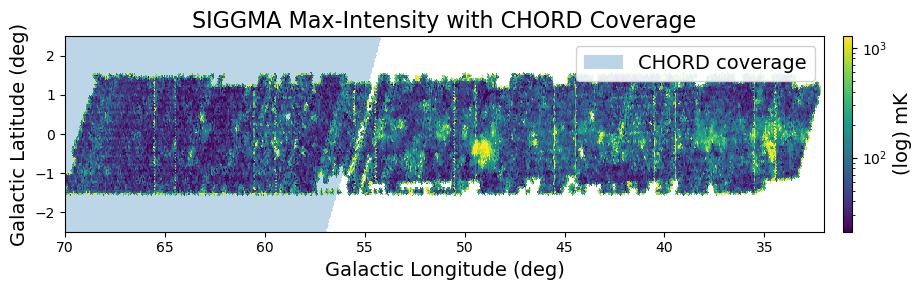

In [44]:
from matplotlib.colors import LogNorm, ListedColormap
from matplotlib.patches import Patch, Rectangle

lonra = [32, 70]
latra = [-2.5, 2.5]
xsize = 2000  # horizontal resolution of the flattened projection

# Zoomed-in view box
zoom_lon = [61, 64.4]
zoom_lat = [-1, 1]

# CHORD coverage mask: 1 where the sensitivity map is valid, NaN elsewhere
chord_mask = np.where(np.isfinite(sensitivity), 1.0, np.nan)

# Project both HEALPix maps onto the same flat lon/lat window. Both are in the
# Galactic frame, so coord='G' (no rotation). return_projected_map gives the 2D
# array; cartview still opens a figure, so close the throwaway ones.
proj_siggma = hp.cartview(SIGGMA_map, coord='G', lonra=lonra, latra=latra,
                          xsize=xsize, return_projected_map=True)
plt.close()
proj_chord = hp.cartview(chord_mask, coord='G', lonra=lonra, latra=latra,
                         xsize=xsize, return_projected_map=True)
plt.close()

# cartview returns masked arrays; fill masked entries with NaN
proj_siggma = np.ma.filled(proj_siggma, np.nan)
proj_chord = np.ma.filled(proj_chord, np.nan)

# cartview displays longitude increasing to the left, so flip the x extent
extent = [lonra[1], lonra[0], latra[0], latra[1]]

fig, ax = plt.subplots(figsize=(10, 3))

# Background layer: solid translucent colour wherever CHORD covers the sky
chord_cmap = ListedColormap(["tab:blue"])
ax.imshow(proj_chord, origin="lower", extent=extent, aspect="auto",
          cmap=chord_cmap, vmin=0, vmax=1, alpha=0.30, interpolation="nearest")

# Foreground layer: SIGGMA map on a log scale, NaNs transparent
siggma_cmap = plt.cm.viridis.copy()
siggma_cmap.set_bad(alpha=0.0)
pos = proj_siggma[np.isfinite(proj_siggma) & (proj_siggma > 0)]
vmin, vmax = np.percentile(pos, [1, 99])
im = ax.imshow(proj_siggma, origin="lower", extent=extent, aspect="auto",
               cmap=siggma_cmap, norm=LogNorm(vmin=vmin, vmax=vmax),
               interpolation="nearest")

# zoom_box = Rectangle((zoom_lon[0], zoom_lat[0]),
#                      zoom_lon[1] - zoom_lon[0], zoom_lat[1] - zoom_lat[0],
#                      fill=False, edgecolor="red", lw=2)
# ax.add_patch(zoom_box)
# ax.text(np.mean(zoom_lon), zoom_lat[1] + 0.1, "Analysis Region",
#         color="red", fontsize=10, ha="center", va="bottom")

ax.set_xlabel("Galactic Longitude (deg)", fontsize=14)
ax.set_ylabel("Galactic Latitude (deg)", fontsize=14)
ax.set_title("SIGGMA Max-Intensity with CHORD Coverage", fontsize=16)
ax.legend(handles=[Patch(facecolor="tab:blue", alpha=0.30, label="CHORD coverage")],
          loc="upper right", fontsize=14, framealpha=0.9)

cbar = fig.colorbar(im, ax=ax, pad=0.02)
cbar.set_label("(log) mK", fontsize=14)

plt.tight_layout()
plt.savefig("../../thesis/plots/siggma/siggma_with_chord_coverage.png", dpi=150, bbox_inches="tight")
plt.show()

## Next looking at H2 regions

In [45]:
# Data Available here: https://cdsarc.cds.unistra.fr/viz-bin/nph-Cat/html?J/ApJS/240/14/table2.dat
cols = [
    "Name", "f_Name", "GLON", "GLAT", "Peak [mJy/beam]", "e_Peak [mJy/beam]",
    "VLSR [km/s]", "e_VLSR [km/s]", "FWHM [km/s]", "e_FWHM [km/s]", "RMS [mJy/beam]", "S/N"
]

data = [
    ["G056.083-00.176", "", 56.083, -0.175, 5.13, 0.63, 46.8, 0.9, 15.6, 2.2, 0.86, 8.0],
    ["G057.541-00.279", "a", 57.542, -0.279, 6.66, 0.73, -1.4, 1.0, 26.6, 3.4, 0.91, 12.9],
    ["G057.545-00.275", "a", 57.546, -0.274, 5.24, 0.75, -17.2, 1.5, 16.1, 3.8, 0.96, 7.5],
    ["G059.321-00.223", "", 59.321, -0.222, 12.41, 0.43, 26.2, 0.4, 23.7, 1.0, 0.72, 28.5],
    ["G059.600+00.316", "", 59.600, +0.316, 2.34, 0.35, 35.0, 2.1, 28.6, 5.0, 0.65, 6.6],
    ["G059.796+00.241", "", 59.797, +0.241, 12.45, 1.14, -2.9, 1.5, 33.2, 3.5, 2.28, 10.7],
    ["G060.881-00.135", "", 60.881, -0.135, 5.75, 0.81, 10.7, 4.2, 28.2, 6.0, 0.82, 12.7],
    ["G061.292-00.331", "", 61.292, -0.331, 8.38, 1.72, 91.9, 4.2, 41.2, 9.8, 3.64, 5.0],
    ["G061.467+00.380", "", 61.467, +0.380, 3.89, 0.30, 21.2, 0.8, 20.5, 1.8, 0.47, 12.9],
    ["G061.473+00.094", "", 61.473, +0.095, 34.86, 2.69, 27.2, 1.1, 30.1, 2.7, 5.11, 12.8],
    ["G062.921+00.079", "", 62.921, +0.079, 10.72, 0.40, 21.0, 0.4, 23.8, 1.0, 0.67, 26.7],
    ["G063.052-00.332", "", 63.052, -0.332, 4.15, 0.36, -2.9, 1.8, 43.5, 4.4, 0.81, 11.5],
    ["G063.164+00.449", "", 63.164, +0.449, 69.45, 4.06, 19.5, 0.5, 16.5, 1.1, 5.71, 16.9],
    ["G064.130-00.475", "", 64.131, -0.474, 4.54, 0.30, 26.8, 0.9, 27.9, 2.1, 0.55, 14.9],
]
data_2 = [
    ["G055.567+00.701", "", 55.568, +0.701, 7.53, 0.28, -1.3, 0.4, 19.1, 0.8, 0.42, 26.6],
    ["G056.725-00.179", "", 56.725, -0.178, 7.81, 0.65, 39.4, 3.1, 75.8, 7.3, 1.96, 11.8],
    ["G057.624+00.410 b", "", 57.625, +0.410, 5.46, 0.58, 94.1, 6.7, 74.4, 12.1, 0.74, 21.8],
    ["G057.624+00.410 b", "", 57.625, +0.410, 5.07, 1.13, 38.3, 1.4, 14.5, 4.0, 0.74, 9.0],
    ["G057.715+00.173", "", 57.715, +0.174, 1.95, 0.26, 42.7, 2.6, 33.8, 7.2, 0.29, 13.3],
    ["G057.715+00.173", "", 57.715, +0.174, 1.80, 0.29, 0.1, 2.0, 22.7, 4.9, 0.29, 10.0],
    ["G057.715+00.173", "", 57.715, +0.174, 1.71, 0.17, 108.7, 4.4, 68.7, 11.3, 0.29, 16.6],
    ["G061.053-00.825 b", "", 61.054, -0.825, 1.91, 0.32, 5.1, 3.9, 47.9, 9.3, 0.77, 5.9],
    ["G061.144-00.891", "", 61.144, -0.891, 2.51, 0.46, 7.8, 1.7, 18.4, 3.9, 0.69, 5.4],
    ["G062.142-00.144", "", 62.142, -0.143, 1.68, 0.26, 14.1, 5.0, 63.9, 11.7, 0.73, 6.2],
    ["G063.050-00.124", "", 63.051, -0.124, 6.53, 0.25, 26.5, 0.5, 24.9, 1.1, 0.43, 26.0],
    ["G067.816+00.511", "", 67.816, +0.511, 2.72, 0.49, 2.0, 1.7, 19.1, 4.0, 0.75, 5.4],
]

H2_regions = pd.DataFrame(data, columns=cols)
H2_regions["candidate"] = False
H2_regions_2 = pd.DataFrame(data_2, columns=cols)
H2_regions_2["candidate"] = True
H2_regions = pd.concat([H2_regions, H2_regions_2], ignore_index=True)

H2_regions['Peak [mK]'] = H2_regions['Peak [mJy/beam]'] * 10  # Convert mJy/beam to mK
H2_regions['e_Peak [mK]'] = H2_regions['e_Peak [mJy/beam]'] * 10
H2_regions = H2_regions[["Name", "GLON", "GLAT", "Peak [mK]", "e_Peak [mK]", "FWHM [km/s]", "e_FWHM [km/s]", "RMS [mJy/beam]", "S/N", "VLSR [km/s]", "e_VLSR [km/s]", "candidate"]]
H2_regions

,Name,GLON,GLAT,Peak [mK],e_Peak [mK],FWHM [km/s],e_FWHM [km/s],RMS [mJy/beam],S/N,VLSR [km/s],e_VLSR [km/s],candidate
0,G056.083-00.176,56.083,-0.175,51.3,6.3,15.6,2.2,0.86,8.0,46.8,0.9,False
1,G057.541-00.279,57.542,-0.279,66.6,7.3,26.6,3.4,0.91,12.9,-1.4,1.0,False
2,G057.545-00.275,57.546,-0.274,52.4,7.5,16.1,3.8,0.96,7.5,-17.2,1.5,False
3,G059.321-00.223,59.321,-0.222,124.1,4.3,23.7,1.0,0.72,28.5,26.2,0.4,False
4,G059.600+00.316,59.600,0.316,23.4,3.5,28.6,5.0,0.65,6.6,35.0,2.1,False
5,G059.796+00.241,59.797,0.241,124.5,11.4,33.2,3.5,2.28,10.7,-2.9,1.5,False
6,G060.881-00.135,60.881,-0.135,57.5,8.1,28.2,6.0,0.82,12.7,10.7,4.2,False
7,G061.292-00.331,61.292,-0.331,83.8,17.2,41.2,9.8,3.64,5.0,91.9,4.2,False
8,G061.467+00.380,61.467,0.380,38.9,3.0,20.5,1.8,0.47,12.9,21.2,0.8,False
9,G061.473+00.094,61.473,0.095,348.6,26.9,30.1,2.7,5.11,12.8,27.2,1.1,False


In [46]:
from astropy.coordinates import SkyCoord

# Check that each H2 region is within the CHORD observable range (dec 20-80 degrees)
# Convert Galactic (l, b) to equatorial declination

import astropy.units as u

# Convert each H2 region's Galactic coordinates to equatorial
coords = SkyCoord(l=H2_regions['GLON'].values * u.deg,
                  b=H2_regions['GLAT'].values * u.deg,
                  frame='galactic')
equatorial = coords.icrs

H2_regions_check = H2_regions.copy()
H2_regions_check['RA'] = equatorial.ra.deg
H2_regions_check['Dec'] = equatorial.dec.deg
H2_regions_check['In_CHORD_Range'] = (H2_regions_check['Dec'] >= 20) & (H2_regions_check['Dec'] <= 80)

print(H2_regions_check[['Name', 'GLON', 'GLAT', 'RA', 'Dec', 'In_CHORD_Range']])

                 Name    GLON   GLAT          RA        Dec  In_CHORD_Range
0     G056.083-00.176  56.083 -0.175  294.055357  20.396244            True
1     G057.541-00.279  57.542 -0.279  294.918282  21.617125            True
2     G057.545-00.275  57.546 -0.274  294.915719  21.623069            True
3     G059.321-00.223  59.321 -0.222  295.817330  23.191045            True
4     G059.600+00.316  59.600  0.316  295.459388  23.700404            True
5     G059.796+00.241  59.797  0.241  295.637331  23.834242            True
6     G060.881-00.135  60.881 -0.135  296.588214  24.585454            True
7     G061.292-00.331  61.292 -0.331  297.002544  24.841719            True
8     G061.467+00.380  61.467  0.380  296.421377  25.350792            True
9     G061.473+00.094  61.473  0.095  296.697247  25.212815            True
10    G062.921+00.079  62.921  0.079  297.526482  26.453756            True
11    G063.052-00.332  63.052 -0.332  297.995761  26.356732            True
12    G063.1

In [47]:
H2_regions.sort_values(by='Peak [mK]', ascending=False, inplace=True, ignore_index=True)
H2_regions.head()

,Name,GLON,GLAT,Peak [mK],e_Peak [mK],FWHM [km/s],e_FWHM [km/s],RMS [mJy/beam],S/N,VLSR [km/s],e_VLSR [km/s],candidate
0,G063.164+00.449,63.164,0.449,694.5,40.6,16.5,1.1,5.71,16.9,19.5,0.5,False
1,G061.473+00.094,61.473,0.095,348.6,26.9,30.1,2.7,5.11,12.8,27.2,1.1,False
2,G059.796+00.241,59.797,0.241,124.5,11.4,33.2,3.5,2.28,10.7,-2.9,1.5,False
3,G059.321-00.223,59.321,-0.222,124.1,4.3,23.7,1.0,0.72,28.5,26.2,0.4,False
4,G062.921+00.079,62.921,0.079,107.2,4.0,23.8,1.0,0.67,26.7,21.0,0.4,False


In [48]:
def df_candidates_to_latex_table(
    df=H2_regions[["Name", "Peak [mK]", "e_Peak [mK]", "FWHM [km/s]", "e_FWHM [km/s]", "S/N", "candidate"]],
    out_path="../../thesis/appendices/siggma_HII.tex",
    caption=("Set of SIGGMA HII regions and candidate HII regions visible to CHORD."),
    label="tab:siggma_candidates",
    fmt="{:.1f}",
    head=None,
    tail=None,
):
    """
    Write a booktabs LaTeX table matching the SIGGMA candidates table (Table 1).

    Expected columns:
        Name, Peak [mK], e_Peak [mK], FWHM [km/s], e_FWHM [km/s], S/N, candidate

    head/tail: if both set and the table is longer than head+tail, only the first
    `head` and last `tail` rows are shown, separated by a \\vdots row (like Table 1).
    """
    def pm(val, err):
        return f"${fmt.format(val)} \\pm {fmt.format(err)}$"

    rows = list(df.iterrows())
    n = len(rows)

    # Decide which rows to display (with an optional vdots break)
    if head is not None and tail is not None and n > head + tail:
        display = list(range(head)) + ["vdots"] + list(range(n - tail, n))
    else:
        display = list(range(n))

    out = [
        r"\begin{table}[H]",
        r"    \centering",
        r"    \begin{tabular}{l c c c c c}",
        r"        \toprule",
        r"        Order & Name & Peak [mK] & FWHM [km/s] & S/N & Type \\",
        r"        \midrule",
    ]

    for pos in display:
        if pos == "vdots":
            out.append(r"        $\vdots$ & $\vdots$ & $\vdots$ & $\vdots$ & $\vdots$ & $\vdots$ \\")
            continue
        _, row = rows[pos]
        order = pos + 1
        peak = pm(row["Peak [mK]"], row["e_Peak [mK]"])
        fwhm = pm(row["FWHM [km/s]"], row["e_FWHM [km/s]"])
        snr = fmt.format(row["S/N"])
        typ = "Candidate" if bool(row["candidate"]) else "Known"
        out.append(f"        {order} & {row['Name']} & {peak} & {fwhm} & {snr} & {typ} \\\\")

    out += [
        r"        \bottomrule",
        r"    \end{tabular}",
        r"    \caption{" + caption + "}",
        r"    \label{" + label + "}",
        r"\end{table}",
    ]

    text = "\n".join(out) + "\n"
    with open(out_path, "w") as f:
        f.write(text)
    return text
df_candidates_to_latex_table()

'\\begin{table}[H]\n    \\centering\n    \\begin{tabular}{l c c c c c}\n        \\toprule\n        Order & Name & Peak [mK] & FWHM [km/s] & S/N & Type \\\\\n        \\midrule\n        1 & G063.164+00.449 & $694.5 \\pm 40.6$ & $16.5 \\pm 1.1$ & 16.9 & Known \\\\\n        2 & G061.473+00.094 & $348.6 \\pm 26.9$ & $30.1 \\pm 2.7$ & 12.8 & Known \\\\\n        3 & G059.796+00.241 & $124.5 \\pm 11.4$ & $33.2 \\pm 3.5$ & 10.7 & Known \\\\\n        4 & G059.321-00.223 & $124.1 \\pm 4.3$ & $23.7 \\pm 1.0$ & 28.5 & Known \\\\\n        5 & G062.921+00.079 & $107.2 \\pm 4.0$ & $23.8 \\pm 1.0$ & 26.7 & Known \\\\\n        6 & G061.292-00.331 & $83.8 \\pm 17.2$ & $41.2 \\pm 9.8$ & 5.0 & Known \\\\\n        7 & G056.725-00.179 & $78.1 \\pm 6.5$ & $75.8 \\pm 7.3$ & 11.8 & Candidate \\\\\n        8 & G055.567+00.701 & $75.3 \\pm 2.8$ & $19.1 \\pm 0.8$ & 26.6 & Candidate \\\\\n        9 & G057.541-00.279 & $66.6 \\pm 7.3$ & $26.6 \\pm 3.4$ & 12.9 & Known \\\\\n        10 & G063.050-00.124 & $65.3 \\pm 2

## Get Noise Maps

In [49]:
# Convert Galactic coordinates (deg) -> HEALPix pixel index for the SNR_map grid
glon = np.mod(H2_regions["GLON"].to_numpy(), 360.0)   # 0..360 deg
glat = H2_regions["GLAT"].to_numpy()                   # -90..90 deg

theta = np.radians(90.0 - glat)  # colatitude
phi = np.radians(glon)           # longitude

pix_idx = hp.ang2pix(nside, theta, phi)
H2_regions["pix_idx"] = pix_idx
H2_regions.head(2)

,Name,GLON,GLAT,Peak [mK],e_Peak [mK],FWHM [km/s],e_FWHM [km/s],RMS [mJy/beam],S/N,VLSR [km/s],e_VLSR [km/s],candidate,pix_idx
0,G063.164+00.449,63.164,0.449,694.5,40.6,16.5,1.1,5.71,16.9,19.5,0.5,False,6240974
1,G061.473+00.094,61.473,0.095,348.6,26.9,30.1,2.7,5.11,12.8,27.2,1.1,False,6281915


In [50]:
H2_regions

,Name,GLON,GLAT,Peak [mK],e_Peak [mK],FWHM [km/s],e_FWHM [km/s],RMS [mJy/beam],S/N,VLSR [km/s],e_VLSR [km/s],candidate,pix_idx
0,G063.164+00.449,63.164,0.449,694.5,40.6,16.5,1.1,5.71,16.9,19.5,0.5,False,6240974
1,G061.473+00.094,61.473,0.095,348.6,26.9,30.1,2.7,5.11,12.8,27.2,1.1,False,6281915
2,G059.796+00.241,59.797,0.241,124.5,11.4,33.2,3.5,2.28,10.7,-2.9,1.5,False,6265512
3,G059.321-00.223,59.321,-0.222,124.1,4.3,23.7,1.0,0.72,28.5,26.2,0.4,False,6314658
4,G062.921+00.079,62.921,0.079,107.2,4.0,23.8,1.0,0.67,26.7,21.0,0.4,False,6281931
5,G061.292-00.331,61.292,-0.331,83.8,17.2,41.2,9.8,3.64,5.0,91.9,4.2,False,6326969
6,G056.725-00.179,56.725,-0.178,78.1,6.5,75.8,7.3,1.96,11.8,39.4,3.1,True,6306437
7,G055.567+00.701,55.568,0.701,75.3,2.8,19.1,0.8,0.42,26.6,-1.3,0.4,True,6212216
8,G057.541-00.279,57.542,-0.279,66.6,7.3,26.6,3.4,0.91,12.9,-1.4,1.0,False,6322830
9,G063.050-00.124,63.051,-0.124,65.3,2.5,24.9,1.1,0.43,26.0,26.5,0.5,True,6306509


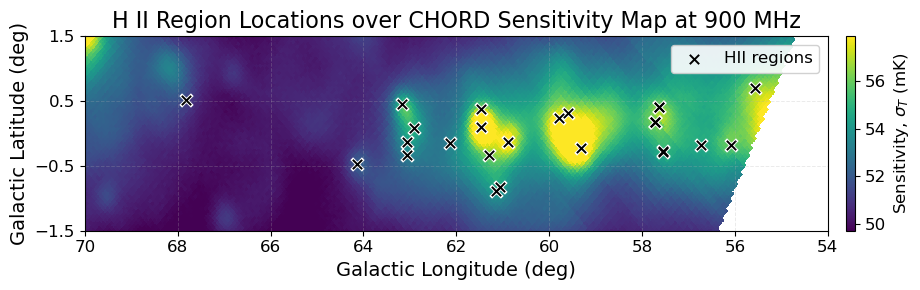

In [62]:
# Thesis-ready plot: CHORD noise map with H2 region positions and clear Galactic axes
noise_map = sky_map.sky_noise(delta_nu=5e3, freq=900e6, type='total_noise', CHORD_range=True)[0]*1e3
lonra = [54, 70]
latra = [-1.5, 1.5]

# Project HEALPix map to a regular lon/lat image grid
proj_noise = hp.cartview(
    noise_map,
    coord="G",
    lonra=lonra,
    latra=latra,
    xsize=1800,
    return_projected_map=True,
    notext=True,
    cbar=False
)
plt.close()  # close temporary healpy figure

proj_noise = np.ma.filled(proj_noise, np.nan)

# Robust log scaling from finite positive pixels
valid = np.isfinite(proj_noise) & (proj_noise > 0)
vmin, vmax = np.percentile(proj_noise[valid], [2, 98])

fig, ax = plt.subplots(figsize=(10, 3))

# healpy cartview has longitude increasing to the left -> reverse x extent
extent = [lonra[1], lonra[0], latra[0], latra[1]]
im = ax.imshow(
    proj_noise,
    origin="lower",
    extent=extent,
    aspect="auto",
    cmap="viridis",
    vmin=vmin, vmax=vmax,
    interpolation="nearest"
)

# Overlay H2 regions (black marker with white outline)
ax.scatter(
    H2_regions_check["GLON"],
    H2_regions_check["GLAT"],
    marker="x",
    s=70,
    c="white",
    linewidths=2.8,
    label="_nolegend_"
)
ax.scatter(
    H2_regions_check["GLON"],
    H2_regions_check["GLAT"],
    marker="x",
    s=45,
    c="black",
    linewidths=1.4,
    label="HII regions"
)

# Axis labels/ticks for thesis quality
ax.set_xlabel(r"Galactic Longitude (deg)", fontsize=14)
ax.set_ylabel(r"Galactic Latitude (deg)", fontsize=14)
ax.set_title(f"H II Region Locations over CHORD Sensitivity Map at 900 MHz", fontsize=16)

ax.set_xlim(lonra[1], lonra[0])
ax.set_ylim(latra[0], latra[1])
ax.set_xticks(np.arange(lonra[1], lonra[0]-1, -2))
ax.set_yticks(np.arange(latra[0], latra[1]+0.1, 1))
ax.tick_params(labelsize=12)
ax.grid(alpha=0.25, linestyle="--", linewidth=0.7)

cbar = fig.colorbar(im, ax=ax, pad=0.02)
cbar.set_label(r"Sensitivity, $\sigma_T$ (mK)", fontsize=12)
cbar.ax.tick_params(labelsize=12)

ax.legend(loc="upper right", fontsize=12, framealpha=0.9)
plt.tight_layout()
plt.savefig("../../thesis/plots/siggma/hii_regions_over_chord_sensitivity.png", dpi=150, bbox_inches="tight")
plt.show()

# GET SNR of native resolution

In [53]:
sky_map = SkyMap('CHORD')

# Get location of the clean lines
f = CLEAN_LINES

# Assume a uniform 10 mK peak line intensity across the sky at 1.5 GHz
f_0 = 1375e6
delta_nu = 5e3  # 5 kHz channel width

# First, get the total noise map for each line
native_noise_maps = np.empty((len(f), hp.nside2npix(nside)))
for i, freq in enumerate(f):
    noise = sky_map.sky_noise(delta_nu=delta_nu, freq=freq, type='total_noise', CHORD_range=True)[0]*1e3
    native_noise_maps[i] = noise



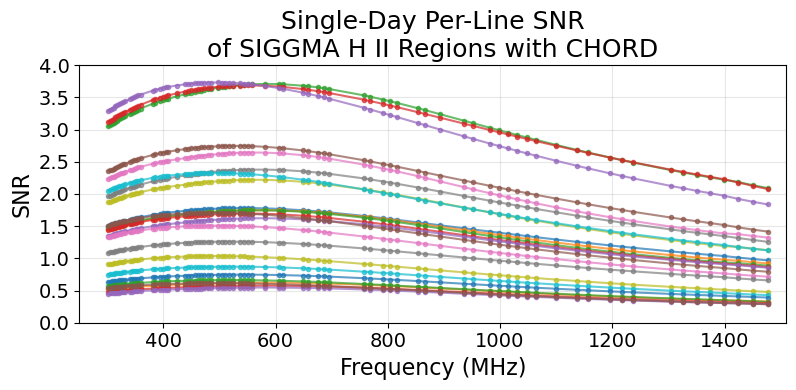

In [59]:
# Next, get noise and signal for each H2 region at each line frequency
noise_array = np.empty((len(H2_regions), len(f)))
signal_array = np.empty((len(H2_regions), len(f)))
native_noise_array = np.empty((len(H2_regions), len(f)))
for i in range(len(H2_regions)):
    signal = H2_regions.loc[i]["Peak [mK]"]
    signal_array[i, :] = signal * f_0/f
    native_noise_array[i, :] = native_noise_maps[:, H2_regions.loc[i]["pix_idx"]]

plt.figure(figsize=(8, 4))

SNR_array = signal_array / native_noise_array
for i in range(SNR_array.shape[0]):
    label = H2_regions.iloc[i]["Name"] if i < len(H2_regions) else None
    plt.plot(f*1e-6, SNR_array[i, :], marker='o', markersize=3, alpha=0.7)

plt.xlabel("Frequency (MHz)", fontsize=16)
plt.ylabel("SNR", fontsize=16)
plt.title("Single-Day Per-Line SNR\nof SIGGMA H II Regions with CHORD", fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.ylim(0,4)
plt.xlim(250, 1510)
plt.savefig("../../thesis/plots/siggma/SNR_per_SIGGMA_line.png", dpi=150, bbox_inches="tight")
plt.show()

In [18]:
scaled_noise_array = native_noise_array*f/f_0
scaled_signal_array = signal_array*f/f_0
weights = 1/(scaled_noise_array**2)

ordered_weights = np.sort(weights, axis=1)[:, ::-1]
lines_to_include = [1, 5, 15, 30, 60]
rms_stacked = pd.DataFrame(index=H2_regions.index)
rms_stacked['name'] = H2_regions['Name']
rms_stacked['signal'] = H2_regions['Peak [mK]']
rms_stacked['signal_error'] = H2_regions['e_Peak [mK]']
for top_n in lines_to_include:
    top_weights = ordered_weights[:, :top_n]
    variance = 1 / np.sum(top_weights, axis=1)
    rms_stacked[f"rms_top_{top_n}"] = np.sqrt(variance)
    rms_stacked[f"SNR_top_{top_n}"] = rms_stacked['signal'] / np.sqrt(variance)
    rms_stacked[f"SNR_top_{top_n}_error"] = rms_stacked['signal_error'] / np.sqrt(variance)

rms_stacked.head()

,name,signal,signal_error,rms_top_1,SNR_top_1,SNR_top_1_error,rms_top_5,SNR_top_5,SNR_top_5_error,rms_top_15,SNR_top_15,SNR_top_15_error,rms_top_30,SNR_top_30,SNR_top_30_error,rms_top_60,SNR_top_60,SNR_top_60_error
0,G063.164+00.449,694.5,40.6,29.496606,23.545082,1.376430,13.194630,52.635049,3.077009,7.633315,90.982750,5.318790,5.453073,127.359370,7.445343,4.048646,171.538822,10.028043
1,G061.473+00.094,348.6,26.9,35.868257,9.718900,0.749967,16.048033,21.722288,1.676218,9.303265,37.470714,2.891458,6.654636,52.384537,4.042295,4.928497,70.731504,5.458054
2,G059.796+00.241,124.5,11.4,33.577378,3.707854,0.339514,15.033727,8.281380,0.758295,8.728748,14.263214,1.306029,6.262147,19.881360,1.820462,4.660675,26.712868,2.445998
3,G059.321-00.223,124.1,4.3,33.676601,3.685051,0.127685,15.067094,8.236492,0.285390,8.731767,14.212472,0.492455,6.245410,19.870594,0.688506,4.632644,26.788156,0.928196
4,G062.921+00.079,107.2,4.0,28.734217,3.730744,0.139207,12.854223,8.339671,0.311182,7.435768,14.416803,0.537940,5.312023,20.180634,0.753009,3.949744,27.140999,1.012724


In [19]:
rms_stacked

,name,signal,signal_error,rms_top_1,SNR_top_1,SNR_top_1_error,rms_top_5,SNR_top_5,SNR_top_5_error,rms_top_15,SNR_top_15,SNR_top_15_error,rms_top_30,SNR_top_30,SNR_top_30_error,rms_top_60,SNR_top_60,SNR_top_60_error
0,G063.164+00.449,694.5,40.6,29.496606,23.545082,1.376430,13.194630,52.635049,3.077009,7.633315,90.982750,5.318790,5.453073,127.359370,7.445343,4.048646,171.538822,10.028043
1,G061.473+00.094,348.6,26.9,35.868257,9.718900,0.749967,16.048033,21.722288,1.676218,9.303265,37.470714,2.891458,6.654636,52.384537,4.042295,4.928497,70.731504,5.458054
2,G059.796+00.241,124.5,11.4,33.577378,3.707854,0.339514,15.033727,8.281380,0.758295,8.728748,14.263214,1.306029,6.262147,19.881360,1.820462,4.660675,26.712868,2.445998
3,G059.321-00.223,124.1,4.3,33.676601,3.685051,0.127685,15.067094,8.236492,0.285390,8.731767,14.212472,0.492455,6.245410,19.870594,0.688506,4.632644,26.788156,0.928196
4,G062.921+00.079,107.2,4.0,28.734217,3.730744,0.139207,12.854223,8.339671,0.311182,7.435768,14.416803,0.537940,5.312023,20.180634,0.753009,3.949744,27.140999,1.012724
5,G061.292-00.331,83.8,17.2,30.517338,2.745980,0.563614,13.651612,6.138469,1.259924,7.904744,10.601229,2.175909,5.654027,14.821294,3.042079,4.203444,19.936034,4.091883
6,G056.725-00.179,78.1,6.5,29.549612,2.643013,0.219969,13.223291,5.906245,0.491557,7.674942,10.175972,0.846912,5.498364,14.204225,1.182170,4.095758,19.068508,1.587008
7,G055.567+00.701,75.3,2.8,31.669559,2.377678,0.088413,14.176476,5.311616,0.197510,8.228391,9.151243,0.340285,5.901207,12.760101,0.474479,4.397151,17.124726,0.636776
8,G057.541-00.279,66.6,7.3,30.003583,2.219735,0.243304,13.426981,4.960162,0.543681,7.793434,8.545655,0.936686,5.583780,11.927405,1.307358,4.156993,16.021197,1.756077
9,G063.050-00.124,65.3,2.5,28.084243,2.325147,0.089018,12.563117,5.197755,0.198995,7.266967,8.985867,0.344022,5.191719,12.577723,0.481536,3.863178,16.903183,0.647136


In [20]:
def df_to_latex_snr_table(
    df=rms_stacked[["name", "SNR_top_1", "SNR_top_1_error", "SNR_top_15", "SNR_top_15_error", "SNR_top_60", "SNR_top_60_error"]],
    out_path="../../thesis/appendices/siggma_stacked_snr.tex",
    caption=("SNR for CHORD observations of SIGGMA HII regions using one observing "
             "day, showing the SNR for the top 1, 15 and 60 stacked lines."),
    label="tab:siggma_stacked_snr",
    fmt="{:.2f}",
    tops=(1, 15, 60),
    head=None,
    tail=None,
):
    """
    Write a booktabs LaTeX table matching the stacked-SNR table (Table 2).

    Expected columns:
        name, and for each n in `tops`:  SNR_top_{n}, SNR_top_{n}_error

    head/tail: if both set and the table is longer than head+tail, only the first
    `head` and last `tail` rows are shown, separated by a \\vdots row (like Table 2).
    """
    def pm(val, err):
        return f"${fmt.format(val)} \\pm {fmt.format(err)}$"

    rows = list(df.iterrows())
    n = len(rows)
    ncol = 2 + len(tops)  # Order + Name + one column per top-n

    if head is not None and tail is not None and n > head + tail:
        display = list(range(head)) + ["vdots"] + list(range(n - tail, n))
    else:
        display = list(range(n))

    col_spec = "l " + " ".join(["c"] * (ncol - 1))
    header = "Order & Name & " + " & ".join(f"SNR top {t}" for t in tops)

    out = [
        r"\begin{table}[H]",
        r"    \centering",
        rf"    \begin{{tabular}}{{{col_spec}}}",
        r"        \toprule",
        f"        {header} \\\\",
        r"        \midrule",
    ]

    vdots_row = " & ".join([r"$\vdots$"] * ncol)
    for pos in display:
        if pos == "vdots":
            out.append(f"        {vdots_row} \\\\")
            continue
        _, row = rows[pos]
        order = pos + 1
        cells = [pm(row[f"SNR_top_{t}"], row[f"SNR_top_{t}_error"]) for t in tops]
        out.append(f"        {order} & {row['name']} & " + " & ".join(cells) + r" \\")

    out += [
        r"        \bottomrule",
        r"    \end{tabular}",
        r"    \caption{" + caption + "}",
        r"    \label{" + label + "}",
        r"\end{table}",
    ]

    text = "\n".join(out) + "\n"
    with open(out_path, "w") as f:
        f.write(text)
    return text
df_to_latex_snr_table()

'\\begin{table}[H]\n    \\centering\n    \\begin{tabular}{l c c c c}\n        \\toprule\n        Order & Name & SNR top 1 & SNR top 15 & SNR top 60 \\\\\n        \\midrule\n        1 & G063.164+00.449 & $23.55 \\pm 1.38$ & $90.98 \\pm 5.32$ & $171.54 \\pm 10.03$ \\\\\n        2 & G061.473+00.094 & $9.72 \\pm 0.75$ & $37.47 \\pm 2.89$ & $70.73 \\pm 5.46$ \\\\\n        3 & G059.796+00.241 & $3.71 \\pm 0.34$ & $14.26 \\pm 1.31$ & $26.71 \\pm 2.45$ \\\\\n        4 & G059.321-00.223 & $3.69 \\pm 0.13$ & $14.21 \\pm 0.49$ & $26.79 \\pm 0.93$ \\\\\n        5 & G062.921+00.079 & $3.73 \\pm 0.14$ & $14.42 \\pm 0.54$ & $27.14 \\pm 1.01$ \\\\\n        6 & G061.292-00.331 & $2.75 \\pm 0.56$ & $10.60 \\pm 2.18$ & $19.94 \\pm 4.09$ \\\\\n        7 & G056.725-00.179 & $2.64 \\pm 0.22$ & $10.18 \\pm 0.85$ & $19.07 \\pm 1.59$ \\\\\n        8 & G055.567+00.701 & $2.38 \\pm 0.09$ & $9.15 \\pm 0.34$ & $17.12 \\pm 0.64$ \\\\\n        9 & G057.541-00.279 & $2.22 \\pm 0.24$ & $8.55 \\pm 0.94$ & $16.02 \\pm 1

## GET SNR of smoothed resolution

In [21]:
chord_telescope = Telescope('CHORD')
s_fwhm = chord_telescope.S_FWHM(f)  # Beam FWHM in radians
avg_s_fwhm = np.degrees(np.sqrt(s_fwhm[:,0]*s_fwhm[:,1]))*60  # Geometric mean of FWHM in arcminutes

# Get location of the clean lines
f = CLEAN_LINES
# Assume a uniform 10 mK peak line intensity across the sky at 1.5 GHz
f_0 = 1375e6
delta_c = 5  # 5 km/s channel width
smoothed_resolution  = 22 # arcmin
c = 3e5  # speed of light in km/s

filtered_f = f[avg_s_fwhm < smoothed_resolution]

# First, get the total noise map for each line
smoothed_noise_maps = np.empty((len(filtered_f), hp.nside2npix(nside)))
for i, freq in enumerate(filtered_f):
    delta_nu = delta_c * freq / c  # Convert km/s to Hz
    noise = sky_map.sky_noise(delta_nu=delta_nu, freq=freq, type='total_noise',
                              smoothed_resolution=smoothed_resolution, CHORD_range=True)[0]*1e3
    smoothed_noise_maps[i] = noise

# Next, get noise and signal for each H2 region at each line frequency
smoothed_noise_array = np.empty((len(H2_regions), len(filtered_f)))
signal_array = np.empty((len(H2_regions), len(filtered_f)))
for i in range(len(H2_regions)):
    signal = H2_regions.loc[i]["Peak [mK]"]
    signal_array[i, :] = signal * f_0/filtered_f
    smoothed_noise_array[i, :] = smoothed_noise_maps[:, H2_regions.loc[i]["pix_idx"]]

In [22]:
def fwhm_to_resolution(fwhm):
    return np.degrees(np.sqrt(np.prod(fwhm, axis=1))) * 60 
f_range = np.linspace(300, 1500, 1500-300) * 1e6
ang_res_values = fwhm_to_resolution(chord_telescope.S_FWHM(f_range))
idx_5 = np.argmin(np.abs(ang_res_values - 5))
idx_6 = np.argmin(np.abs(ang_res_values - 6))
idx_8 = np.argmin(np.abs(ang_res_values - 8))
idx_12 = np.argmin(np.abs(ang_res_values - 12))
idx_22 = np.argmin(np.abs(ang_res_values - 22))
print(f"5 arcmin: index {idx_5}, frequency {f_range[idx_5]*1e-6:.2f} MHz, usable lines {np.sum(avg_s_fwhm < 5)}")
print(f"6 arcmin: index {idx_6}, frequency {f_range[idx_6]*1e-6:.2f} MHz, usable lines {np.sum(avg_s_fwhm < 6)}")
print(f"8 arcmin: index {idx_8}, frequency {f_range[idx_8]*1e-6:.2f} MHz, usable lines {np.sum(avg_s_fwhm < 8)}")
print(f"12 arcmin: index {idx_12}, frequency {f_range[idx_12]*1e-6:.2f} MHz, usable lines {np.sum(avg_s_fwhm < 12)}")
print(f"22 arcmin: index {idx_22}, frequency {f_range[idx_22]*1e-6:.2f} MHz, usable lines {np.sum(avg_s_fwhm < 22)}")

5 arcmin: index 982, frequency 1282.82 MHz, usable lines 8
6 arcmin: index 768, frequency 1068.64 MHz, usable lines 14
8 arcmin: index 501, frequency 801.42 MHz, usable lines 27
12 arcmin: index 234, frequency 534.20 MHz, usable lines 42
22 arcmin: index 0, frequency 300.00 MHz, usable lines 79


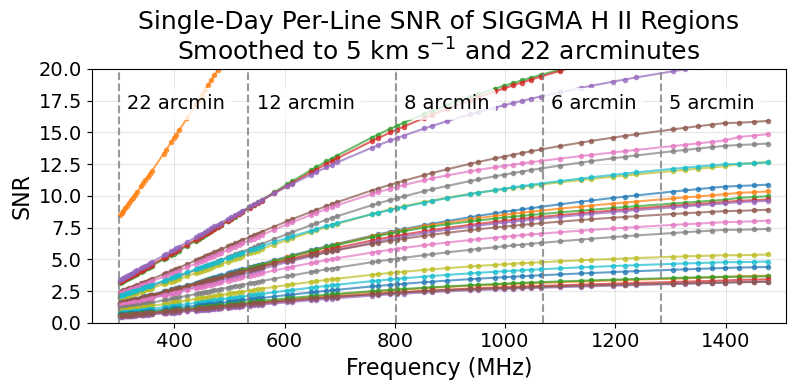

In [63]:
# Next, get noise and signal for each H2 region at each line frequency
smoothed_noise_array = np.empty((len(H2_regions), len(filtered_f)))
signal_array = np.empty((len(H2_regions), len(filtered_f)))
for i in range(len(H2_regions)):
    signal = H2_regions.loc[i]["Peak [mK]"]
    signal_array[i, :] = signal * f_0/filtered_f
    smoothed_noise_array[i, :] = smoothed_noise_maps[:, H2_regions.loc[i]["pix_idx"]]
plt.figure(figsize=(8, 4))

SNR_array = signal_array / smoothed_noise_array
for i in range(SNR_array.shape[0]):
    label = H2_regions.iloc[i]["Name"] if i < len(H2_regions) else None
    plt.plot(filtered_f*1e-6, SNR_array[i, :], marker='o', markersize=3, alpha=0.7)

for i, label in zip([idx_5, idx_6, idx_8, idx_12, idx_22], ["5 arcmin", "6 arcmin", "8 arcmin", "12 arcmin", "22 arcmin"]):
    plt.axvline(f_range[i]*1e-6, color='gray', linestyle='--', alpha=0.8)
    plt.text(f_range[i]*1e-6 + 15, 18, label, rotation=0, verticalalignment='top', fontsize=14, bbox=dict(boxstyle='round', facecolor='white', edgecolor='white', alpha=0.8))
plt.xlabel("Frequency (MHz)", fontsize=16)
plt.ylabel("SNR", fontsize=16)
plt.title("Single-Day Per-Line SNR of SIGGMA H II Regions\nSmoothed to 5 km s$^{-1}$ and 22 arcminutes", fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.ylim(0,20)
plt.xlim(250, 1510)
plt.savefig("../../thesis/plots/siggma/SNR_per_SIGGMA_line_smoothed.png", dpi=150, bbox_inches="tight")
plt.show()

In [56]:
angular_cutoffs = [5, 6, 8, 12]

noise_results = {}
for cutoff in angular_cutoffs:
    usable_lines = CLEAN_LINES[avg_s_fwhm < cutoff]
    noise_maps = np.empty((len(usable_lines), hp.nside2npix(nside)))
    for i, line in enumerate(usable_lines):
        delta_nu = delta_c * line / c  # Convert km/s to Hz
        noise = sky_map.sky_noise(delta_nu=delta_nu, freq=line, type='total_noise',
                                  smoothed_resolution=cutoff, CHORD_range=True)[0]*1e3
        noise_maps[i] = noise

    noise_results[cutoff] = {
        "lines": usable_lines,
        "noise_maps": noise_maps
    }



In [57]:
noise_results[5]["noise_maps"][:, 10]

array([784.6121999 , 825.12459793, 866.07809135, 899.61986985,
       922.83086805, 945.98570221, 969.20842936, 992.49380314])

In [58]:
H2_regions

,Name,GLON,GLAT,Peak [mK],e_Peak [mK],FWHM [km/s],e_FWHM [km/s],RMS [mJy/beam],S/N,VLSR [km/s],e_VLSR [km/s],candidate,pix_idx
0,G063.164+00.449,63.164,0.449,694.5,40.6,16.5,1.1,5.71,16.9,19.5,0.5,False,6240974
1,G061.473+00.094,61.473,0.095,348.6,26.9,30.1,2.7,5.11,12.8,27.2,1.1,False,6281915
2,G059.796+00.241,59.797,0.241,124.5,11.4,33.2,3.5,2.28,10.7,-2.9,1.5,False,6265512
3,G059.321-00.223,59.321,-0.222,124.1,4.3,23.7,1.0,0.72,28.5,26.2,0.4,False,6314658
4,G062.921+00.079,62.921,0.079,107.2,4.0,23.8,1.0,0.67,26.7,21.0,0.4,False,6281931
5,G061.292-00.331,61.292,-0.331,83.8,17.2,41.2,9.8,3.64,5.0,91.9,4.2,False,6326969
6,G056.725-00.179,56.725,-0.178,78.1,6.5,75.8,7.3,1.96,11.8,39.4,3.1,True,6306437
7,G055.567+00.701,55.568,0.701,75.3,2.8,19.1,0.8,0.42,26.6,-1.3,0.4,True,6212216
8,G057.541-00.279,57.542,-0.279,66.6,7.3,26.6,3.4,0.91,12.9,-1.4,1.0,False,6322830
9,G063.050-00.124,63.051,-0.124,65.3,2.5,24.9,1.1,0.43,26.0,26.5,0.5,True,6306509


In [27]:
region_SNR_results = pd.DataFrame()
region_SNR_results['Name'] = H2_regions['Name']
region_SNR_results['signal'] = H2_regions['Peak [mK]']
region_SNR_results['signal_error'] = H2_regions['e_Peak [mK]']
for cutoff in angular_cutoffs:
    usable_lines = noise_results[cutoff]["lines"]
    noise_maps = noise_results[cutoff]["noise_maps"]

    for i in range(len(H2_regions)):
        signal = H2_regions.loc[i]["Peak [mK]"] # Signal
        error = H2_regions.loc[i]["e_Peak [mK]"] # Signal error
        smoothed_noise_array = noise_maps[:, H2_regions.loc[i]["pix_idx"]] # Noise per line for this H2 region
        scaled_noise_array = smoothed_noise_array * usable_lines / f_0 # Scaled noise to 1375 MHz
        weight_array = 1/(scaled_noise_array**2) # Weighting for inverse variance stacking
        variance = 1 / np.sum(weight_array) # Variance after stacking
        rms = np.sqrt(variance) # RMS from the variance
        SNR = signal / rms # Signal-to-noise ratio
        region_SNR_results.loc[i, f"SNR {cutoff} arcmins"] = SNR
        region_SNR_results.loc[i, f"error {cutoff} arcmins"] = error / rms

region_SNR_results

,Name,signal,signal_error,SNR 5 arcmins,error 5 arcmins,SNR 6 arcmins,error 6 arcmins,SNR 8 arcmins,error 8 arcmins,SNR 12 arcmins,error 12 arcmins
0,G063.164+00.449,694.5,40.6,85.042969,4.971554,130.521165,7.630179,222.375963,12.999948,368.232978,21.526651
1,G061.473+00.094,348.6,26.9,41.859730,3.230140,63.485773,4.898931,105.471131,8.138765,171.582532,13.240304
2,G059.796+00.241,124.5,11.4,14.701445,1.346156,22.446888,2.055378,37.984006,3.478054,62.374792,5.711427
3,G059.321-00.223,124.1,4.3,14.703489,0.509468,22.436459,0.777412,37.788894,1.309365,61.964443,2.147035
4,G062.921+00.079,107.2,4.0,13.046812,0.486821,20.076529,0.749124,34.374254,1.282621,57.110666,2.130995
5,G061.292-00.331,83.8,17.2,10.040689,2.060857,15.434439,3.167928,26.347892,5.407921,43.597666,8.948447
6,G056.725-00.179,78.1,6.5,9.240914,0.769090,14.214072,1.182989,24.568970,2.044793,40.954954,3.408543
7,G055.567+00.701,75.3,2.8,8.906876,0.331199,13.700262,0.509439,23.420813,0.870893,38.682661,1.438399
8,G057.541-00.279,66.6,7.3,7.916686,0.867745,12.179858,1.335030,20.987338,2.300414,34.888725,3.824140
9,G063.050-00.124,65.3,2.5,7.977150,0.305404,12.291850,0.470591,21.109938,0.808191,35.149742,1.345702


In [28]:
region_SNR_results[["Name", "SNR 5 arcmins", "error 5 arcmins", "SNR 6 arcmins", "error 6 arcmins", "SNR 8 arcmins", "error 8 arcmins", "SNR 12 arcmins", "error 12 arcmins"]]

,Name,SNR 5 arcmins,error 5 arcmins,SNR 6 arcmins,error 6 arcmins,SNR 8 arcmins,error 8 arcmins,SNR 12 arcmins,error 12 arcmins
0,G063.164+00.449,85.042969,4.971554,130.521165,7.630179,222.375963,12.999948,368.232978,21.526651
1,G061.473+00.094,41.859730,3.230140,63.485773,4.898931,105.471131,8.138765,171.582532,13.240304
2,G059.796+00.241,14.701445,1.346156,22.446888,2.055378,37.984006,3.478054,62.374792,5.711427
3,G059.321-00.223,14.703489,0.509468,22.436459,0.777412,37.788894,1.309365,61.964443,2.147035
4,G062.921+00.079,13.046812,0.486821,20.076529,0.749124,34.374254,1.282621,57.110666,2.130995
5,G061.292-00.331,10.040689,2.060857,15.434439,3.167928,26.347892,5.407921,43.597666,8.948447
6,G056.725-00.179,9.240914,0.769090,14.214072,1.182989,24.568970,2.044793,40.954954,3.408543
7,G055.567+00.701,8.906876,0.331199,13.700262,0.509439,23.420813,0.870893,38.682661,1.438399
8,G057.541-00.279,7.916686,0.867745,12.179858,1.335030,20.987338,2.300414,34.888725,3.824140
9,G063.050-00.124,7.977150,0.305404,12.291850,0.470591,21.109938,0.808191,35.149742,1.345702


In [29]:
def df_to_latex_snr_table(
    df=region_SNR_results[["Name", "SNR 5 arcmins", "error 5 arcmins", "SNR 6 arcmins", "error 6 arcmins", "SNR 8 arcmins", "error 8 arcmins", "SNR 12 arcmins", "error 12 arcmins"]],
    out_path="../../thesis/appendices/siggma_stacked_snr_smoothed.tex",
    caption=("SNR for CHORD observations of SIGGMA HII regions with a smoothed "
             "angular resolution of 5, 6, 8 and 12 arcminutes."),
    label="tab:siggma_stacked_snr",
    fmt="{:.2f}",
    resolutions=(5, 6, 8, 12),
    head=None,
    tail=None,
):
    """
    Write a booktabs LaTeX table matching the stacked-SNR table (Table 2).

    Expected columns:
        Name, and for each a in `resolutions`:  "SNR {a} arcmins", "error {a} arcmins"

    head/tail: if both set and the table is longer than head+tail, only the first
    `head` and last `tail` rows are shown, separated by a \\vdots row (like Table 2).
    """
    def pm(val, err):
        return f"${fmt.format(val)} \\pm {fmt.format(err)}$"

    rows = list(df.iterrows())
    n = len(rows)
    ncol = 2 + len(resolutions)  # Order + Name + one column per resolution

    if head is not None and tail is not None and n > head + tail:
        display = list(range(head)) + ["vdots"] + list(range(n - tail, n))
    else:
        display = list(range(n))

    col_spec = "l " + " ".join(["c"] * (ncol - 1))
    header = "Order & Name & " + " & ".join(f"SNR ${a}'$" for a in resolutions)

    out = [
        r"\begin{table}[H]",
        r"    \centering",
        rf"    \begin{{tabular}}{{{col_spec}}}",
        r"        \toprule",
        f"        {header} \\\\",
        r"        \midrule",
    ]

    vdots_row = " & ".join([r"$\vdots$"] * ncol)
    for pos in display:
        if pos == "vdots":
            out.append(f"        {vdots_row} \\\\")
            continue
        _, row = rows[pos]
        order = pos + 1
        cells = [pm(row[f"SNR {a} arcmins"], row[f"error {a} arcmins"]) for a in resolutions]
        out.append(f"        {order} & {row['Name']} & " + " & ".join(cells) + r" \\")

    out += [
        r"        \bottomrule",
        r"    \end{tabular}",
        r"    \caption{" + caption + "}",
        r"    \label{" + label + "}",
        r"\end{table}",
    ]

    text = "\n".join(out) + "\n"
    with open(out_path, "w") as f:
        f.write(text)
    return text
df_to_latex_snr_table()

"\\begin{table}[H]\n    \\centering\n    \\begin{tabular}{l c c c c c}\n        \\toprule\n        Order & Name & SNR $5'$ & SNR $6'$ & SNR $8'$ & SNR $12'$ \\\\\n        \\midrule\n        1 & G063.164+00.449 & $85.04 \\pm 4.97$ & $130.52 \\pm 7.63$ & $222.38 \\pm 13.00$ & $368.23 \\pm 21.53$ \\\\\n        2 & G061.473+00.094 & $41.86 \\pm 3.23$ & $63.49 \\pm 4.90$ & $105.47 \\pm 8.14$ & $171.58 \\pm 13.24$ \\\\\n        3 & G059.796+00.241 & $14.70 \\pm 1.35$ & $22.45 \\pm 2.06$ & $37.98 \\pm 3.48$ & $62.37 \\pm 5.71$ \\\\\n        4 & G059.321-00.223 & $14.70 \\pm 0.51$ & $22.44 \\pm 0.78$ & $37.79 \\pm 1.31$ & $61.96 \\pm 2.15$ \\\\\n        5 & G062.921+00.079 & $13.05 \\pm 0.49$ & $20.08 \\pm 0.75$ & $34.37 \\pm 1.28$ & $57.11 \\pm 2.13$ \\\\\n        6 & G061.292-00.331 & $10.04 \\pm 2.06$ & $15.43 \\pm 3.17$ & $26.35 \\pm 5.41$ & $43.60 \\pm 8.95$ \\\\\n        7 & G056.725-00.179 & $9.24 \\pm 0.77$ & $14.21 \\pm 1.18$ & $24.57 \\pm 2.04$ & $40.95 \\pm 3.41$ \\\\\n        8 & G

## Compute line stacking

In [30]:
scaled_noise_array = noise_array*f/f_0
scaled_signal_array = signal_array*f/f_0
weights = 1/(scaled_noise_array**2)

ordered_weights = np.sort(weights, axis=1)[:, ::-1]
lines_to_include = [1, 5, 15, 30, 60]
rms_stacked = pd.DataFrame(index=H2_regions.index)
rms_stacked['name'] = H2_regions['Name']
rms_stacked['signal'] = H2_regions['Peak [mK]']
rms_stacked['signal_error'] = H2_regions['e_Peak [mK]']
for top_n in lines_to_include:
    top_weights = ordered_weights[:, :top_n]
    variance = 1 / np.sum(top_weights, axis=1)
    rms_stacked[f"rms_top_{top_n}"] = np.sqrt(variance)
    rms_stacked[f"SNR_top_{top_n}"] = rms_stacked['signal'] / np.sqrt(variance)
    rms_stacked[f"SNR_top_{top_n}_error"] = rms_stacked['signal_error'] / np.sqrt(variance)

rms_stacked

/var/folders/1v/pf54418j6fj5541rk7ynqhgw0000gn/T/ipykernel_6919/3440536273.py:1: RuntimeWarning: overflow encountered in multiply
  scaled_noise_array = noise_array*f/f_0
/var/folders/1v/pf54418j6fj5541rk7ynqhgw0000gn/T/ipykernel_6919/3440536273.py:3: RuntimeWarning: overflow encountered in square
  weights = 1/(scaled_noise_array**2)
/var/folders/1v/pf54418j6fj5541rk7ynqhgw0000gn/T/ipykernel_6919/3440536273.py:3: RuntimeWarning: divide by zero encountered in divide
  weights = 1/(scaled_noise_array**2)
/var/folders/1v/pf54418j6fj5541rk7ynqhgw0000gn/T/ipykernel_6919/3440536273.py:3: RuntimeWarning: overflow encountered in divide
  weights = 1/(scaled_noise_array**2)


,name,signal,signal_error,rms_top_1,SNR_top_1,SNR_top_1_error,rms_top_5,SNR_top_5,SNR_top_5_error,rms_top_15,SNR_top_15,SNR_top_15_error,rms_top_30,SNR_top_30,SNR_top_30_error,rms_top_60,SNR_top_60,SNR_top_60_error
0,G063.164+00.449,694.5,40.6,0.0,inf,inf,0.0,inf,inf,0.0,inf,inf,0.0,inf,inf,0.0,inf,inf
1,G061.473+00.094,348.6,26.9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,G059.796+00.241,124.5,11.4,0.0,inf,inf,0.0,inf,inf,0.0,inf,inf,0.0,inf,inf,0.0,inf,inf
3,G059.321-00.223,124.1,4.3,0.0,inf,inf,0.0,inf,inf,0.0,inf,inf,0.0,inf,inf,0.0,inf,inf
4,G062.921+00.079,107.2,4.0,0.0,inf,inf,0.0,inf,inf,0.0,inf,inf,0.0,inf,inf,0.0,inf,inf
5,G061.292-00.331,83.8,17.2,0.0,inf,inf,0.0,inf,inf,0.0,inf,inf,0.0,inf,inf,0.0,inf,inf
6,G056.725-00.179,78.1,6.5,0.0,inf,inf,0.0,inf,inf,0.0,inf,inf,0.0,inf,inf,0.0,inf,inf
7,G055.567+00.701,75.3,2.8,0.0,inf,inf,0.0,inf,inf,0.0,inf,inf,0.0,inf,inf,0.0,inf,inf
8,G057.541-00.279,66.6,7.3,0.0,inf,inf,0.0,inf,inf,0.0,inf,inf,0.0,inf,inf,0.0,inf,inf
9,G063.050-00.124,65.3,2.5,0.0,inf,inf,0.0,inf,inf,0.0,inf,inf,0.0,inf,inf,0.0,inf,inf


In [31]:
rms_stacked.loc[[0,1, 2, 24, 25]][["name", "SNR_top_1", "SNR_top_1_error", "SNR_top_15", "SNR_top_15_error", "SNR_top_60", "SNR_top_60_error"]]

,name,SNR_top_1,SNR_top_1_error,SNR_top_15,SNR_top_15_error,SNR_top_60,SNR_top_60_error
0,G063.164+00.449,inf,inf,inf,inf,inf,inf
1,G061.473+00.094,NaN,NaN,NaN,NaN,NaN,NaN
2,G059.796+00.241,inf,inf,inf,inf,inf,inf
24,G057.715+00.173,inf,inf,inf,inf,inf,inf
25,G062.142-00.144,inf,inf,inf,inf,inf,inf


In [32]:
rms_stacked[["name", "SNR_top_1", "SNR_top_1_error", "SNR_top_15", "SNR_top_15_error", "SNR_top_60", "SNR_top_60_error"]]

,name,SNR_top_1,SNR_top_1_error,SNR_top_15,SNR_top_15_error,SNR_top_60,SNR_top_60_error
0,G063.164+00.449,inf,inf,inf,inf,inf,inf
1,G061.473+00.094,NaN,NaN,NaN,NaN,NaN,NaN
2,G059.796+00.241,inf,inf,inf,inf,inf,inf
3,G059.321-00.223,inf,inf,inf,inf,inf,inf
4,G062.921+00.079,inf,inf,inf,inf,inf,inf
5,G061.292-00.331,inf,inf,inf,inf,inf,inf
6,G056.725-00.179,inf,inf,inf,inf,inf,inf
7,G055.567+00.701,inf,inf,inf,inf,inf,inf
8,G057.541-00.279,inf,inf,inf,inf,inf,inf
9,G063.050-00.124,inf,inf,inf,inf,inf,inf


In [33]:
def df_to_latex_snr_table(
    df=rms_stacked[["name", "SNR_top_1", "SNR_top_1_error", "SNR_top_15", "SNR_top_15_error", "SNR_top_60", "SNR_top_60_error"]],
    out_path="../../thesis/appendices/siggma_stacked_snr.tex",
    caption=("SNR for CHORD observations of SIGGMA HII regions using one observing "
             "day, showing the SNR for the top 1, 15 and 60 stacked lines."),
    label="tab:siggma_stacked_snr",
    fmt="{:.2f}",
    tops=(1, 15, 60),
    head=None,
    tail=None,
):
    """
    Write a booktabs LaTeX table matching the stacked-SNR table (Table 2).

    Expected columns:
        name, and for each n in `tops`:  SNR_top_{n}, SNR_top_{n}_error

    head/tail: if both set and the table is longer than head+tail, only the first
    `head` and last `tail` rows are shown, separated by a \\vdots row (like Table 2).
    """
    def pm(val, err):
        return f"${fmt.format(val)} \\pm {fmt.format(err)}$"

    rows = list(df.iterrows())
    n = len(rows)
    ncol = 2 + len(tops)  # Order + Name + one column per top-n

    if head is not None and tail is not None and n > head + tail:
        display = list(range(head)) + ["vdots"] + list(range(n - tail, n))
    else:
        display = list(range(n))

    col_spec = "l " + " ".join(["c"] * (ncol - 1))
    header = "Order & Name & " + " & ".join(f"SNR top {t}" for t in tops)

    out = [
        r"\begin{table}[H]",
        r"    \centering",
        rf"    \begin{{tabular}}{{{col_spec}}}",
        r"        \toprule",
        f"        {header} \\\\",
        r"        \midrule",
    ]

    vdots_row = " & ".join([r"$\vdots$"] * ncol)
    for pos in display:
        if pos == "vdots":
            out.append(f"        {vdots_row} \\\\")
            continue
        _, row = rows[pos]
        order = pos + 1
        cells = [pm(row[f"SNR_top_{t}"], row[f"SNR_top_{t}_error"]) for t in tops]
        out.append(f"        {order} & {row['name']} & " + " & ".join(cells) + r" \\")

    out += [
        r"        \bottomrule",
        r"    \end{tabular}",
        r"    \caption{" + caption + "}",
        r"    \label{" + label + "}",
        r"\end{table}",
    ]

    text = "\n".join(out) + "\n"
    with open(out_path, "w") as f:
        f.write(text)
    return text
df_to_latex_snr_table()

'\\begin{table}[H]\n    \\centering\n    \\begin{tabular}{l c c c c}\n        \\toprule\n        Order & Name & SNR top 1 & SNR top 15 & SNR top 60 \\\\\n        \\midrule\n        1 & G063.164+00.449 & $inf \\pm inf$ & $inf \\pm inf$ & $inf \\pm inf$ \\\\\n        2 & G061.473+00.094 & $nan \\pm nan$ & $nan \\pm nan$ & $nan \\pm nan$ \\\\\n        3 & G059.796+00.241 & $inf \\pm inf$ & $inf \\pm inf$ & $inf \\pm inf$ \\\\\n        4 & G059.321-00.223 & $inf \\pm inf$ & $inf \\pm inf$ & $inf \\pm inf$ \\\\\n        5 & G062.921+00.079 & $inf \\pm inf$ & $inf \\pm inf$ & $inf \\pm inf$ \\\\\n        6 & G061.292-00.331 & $inf \\pm inf$ & $inf \\pm inf$ & $inf \\pm inf$ \\\\\n        7 & G056.725-00.179 & $inf \\pm inf$ & $inf \\pm inf$ & $inf \\pm inf$ \\\\\n        8 & G055.567+00.701 & $inf \\pm inf$ & $inf \\pm inf$ & $inf \\pm inf$ \\\\\n        9 & G057.541-00.279 & $inf \\pm inf$ & $inf \\pm inf$ & $inf \\pm inf$ \\\\\n        10 & G063.050-00.124 & $inf \\pm inf$ & $inf \\pm inf$

In [34]:
# Mask SIGGMA map to the selected region and keep only positive values for log scaling
siggma_region = np.where(region_mask, SIGGMA_map, np.nan)
siggma_region = np.where(siggma_region > 0, siggma_region, np.nan)

# Filter H2 regions in the zoomed area
h2_in_region = H2_regions[H2_regions['GLON'].between(zoom_lon[0], zoom_lon[1]) & H2_regions['GLAT'].between(zoom_lat[0], zoom_lat[1])]

# Derive lon/lat bounds from the region mask
pix_in_region = np.where(region_mask)[0]
theta_r, phi_r = hp.pix2ang(nside, pix_in_region)
lon_r = np.degrees(phi_r)
lat_r = 90.0 - np.degrees(theta_r)

hp.cartview(
    siggma_region,
    coord='G',
    lonra=[lon_r.min(), lon_r.max()],
    latra=[lat_r.min(), lat_r.max()],
    cmap='viridis',
    norm='linear',
    title='SIGGMA Max-Intensity (linear scale) in region_mask',
    unit='mK'
)

# Plot H2 region locations as markers
hp.projscatter(
    np.radians(90 - h2_in_region['GLAT']),
    np.radians(h2_in_region['GLON']),
    coord='G', marker='x', s=50, color='red', lw=2
)

# Add text labels next to each marker
for _, row in h2_in_region.iterrows():
    hp.projtext(
        np.radians(90 - row['GLAT']),
        np.radians(row['GLON'] + 0.06),  # small longitude offset
        row['Name'],
        coord='G',
        color='white',
        fontsize=7
    )

hp.graticule(dpar=0.5, dmer=1, coord='G', alpha=0.4, color='black', verbose=False)
plt.show()

NameError: name 'region_mask' is not defined